In [23]:
import sys
sys.path.append("..")

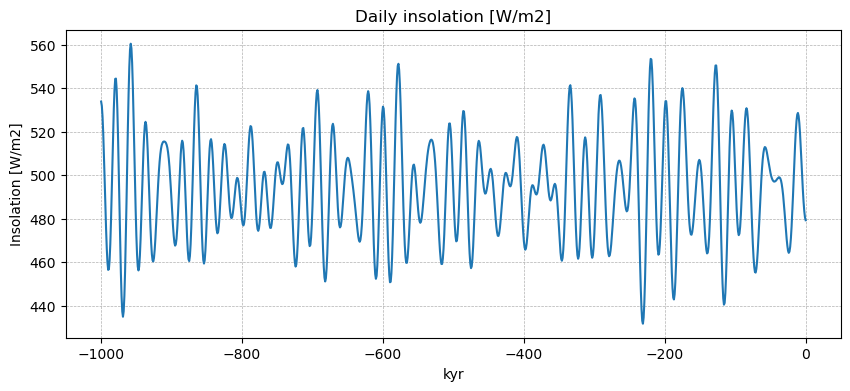

In [24]:
import matplotlib.pyplot as plt
from resources.insolationAstroSeries import compute_insolation_astro_series

result = compute_insolation_astro_series(
    plot_type="Daily insolation",
    solution="Laskar2004",
    solar_constant=1365,
    latitude=65,
    true_longitude1=90,
    true_longitude2=180,
    t_start=-1000,
    t_end=0,
    t_step=1,
    time_unit="kyr"
)

series = result["series"]

plt.figure(figsize=(10, 4))
plt.plot(series.index, series.values)
plt.xlabel("kyr")
plt.ylabel(result["ylabel"])
plt.title(result["short_name"])
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

In [25]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

from resources.insolationAstroSeries import *

In [26]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Widgets
# ------------------------------------------------------------
plot_type = widgets.Dropdown(
    options=PLOT_TYPES,
    value="Daily insolation",
    description="Type:",
    layout=widgets.Layout(width="450px"),
)

solution = widgets.Dropdown(
    options=ASTRO_SOLUTIONS,
    value="Laskar2004",
    description="Solution:",
    layout=widgets.Layout(width="320px"),
)

solar_constant = widgets.FloatText(
    value=1365.0,
    description="S0:",
    layout=widgets.Layout(width="180px"),
)

latitude = widgets.FloatText(
    value=65.0,
    description="Lat:",
    layout=widgets.Layout(width="180px"),
)

true_lon1 = widgets.FloatText(
    value=90.0,
    description="Lon1:",
    layout=widgets.Layout(width="180px"),
)

true_lon2 = widgets.FloatText(
    value=180.0,
    description="Lon2:",
    layout=widgets.Layout(width="180px"),
)

time_unit = widgets.Dropdown(
    options=["yr", "kyr"],
    value="kyr",
    description="Unit:",
    layout=widgets.Layout(width="180px"),
)

time_direction = widgets.Dropdown(
    options=[("Past < 0", 1), ("Past > 0", -1)],
    value=1,
    description="Time:",
    layout=widgets.Layout(width="220px"),
)

t_start = widgets.FloatText(
    value=-1000.0,
    description="Start [kyr]:",
    layout=widgets.Layout(width="180px"),
)

t_end = widgets.FloatText(
    value=0.0,
    description="End [kyr]:",
    layout=widgets.Layout(width="180px"),
)

t_step = widgets.FloatText(
    value=1.0,
    description="Step [kyr]:",
    layout=widgets.Layout(width="180px"),
)

button = widgets.Button(description="Compute", button_style="primary")
out = widgets.Output()

ref_label = widgets.HTML()
range_label = widgets.HTML()

# ------------------------------------------------------------
# State helpers
# ------------------------------------------------------------
_previous_time_unit = time_unit.value


def clip(value, vmin, vmax):
    return max(vmin, min(value, vmax))


def update_time_descriptions():
    t_start.description = f"Start [{time_unit.value}]:"
    t_end.description = f"End [{time_unit.value}]:"
    t_step.description = f"Step [{time_unit.value}]:"


def update_true_lon2_limit(*args):
    min_lon2 = true_lon1.value + 1.0
    if true_lon2.value < min_lon2:
        true_lon2.value = min_lon2


def update_time_bounds(*args):
    scale_factor = 1000 if time_unit.value == "yr" else 1

    lim1, lim2 = get_solution_limits_kyr(solution.value)
    if lim1 is None:
        lim1, lim2 = -5_000_000, 5_000_000

    lim1 = lim1 * time_direction.value * scale_factor
    lim2 = lim2 * time_direction.value * scale_factor

    lo = min(lim1, lim2)
    hi = max(lim1, lim2)

    v_start = clip(t_start.value, lo, hi)
    v_end = clip(t_end.value, lo, hi)

    t_start.value = min(v_start, v_end)
    t_end.value = max(v_start, v_end)

    update_time_descriptions()

    ref_label.value = f"<b>Reference:</b> {get_solution_reference(solution.value)}"
    range_label.value = f"<b>Range:</b> {get_solution_range_label(solution.value)}"


def time_convention_change(change):
    if change["name"] != "value":
        return

    value1 = -t_start.value
    value2 = -t_end.value

    t_start.value = min(value1, value2)
    t_end.value = max(value1, value2)

    update_time_bounds()


def time_unit_change(change):
    global _previous_time_unit

    if change["name"] != "value":
        return

    old_unit = _previous_time_unit
    new_unit = time_unit.value

    if old_unit != new_unit:
        if old_unit == "kyr" and new_unit == "yr":
            t_start.value *= 1000.0
            t_end.value *= 1000.0
            t_step.value *= 1000.0
        elif old_unit == "yr" and new_unit == "kyr":
            t_start.value /= 1000.0
            t_end.value /= 1000.0
            t_step.value /= 1000.0

    _previous_time_unit = new_unit
    update_time_bounds()


def update_widget_state(*args):
    allowed = list(get_allowed_plot_types(solution.value))

    current = plot_type.value
    plot_type.options = allowed

    if current in allowed:
        plot_type.value = current
    else:
        plot_type.value = allowed[0]

    current_type = plot_type.value

    is_orbital = current_type in [
        "Eccentricity",
        "Obliquity",
        "Precession angle",
        "Precession parameter",
    ]
    is_daily = current_type == "Daily insolation"
    is_integrated = current_type == "Integrated insolation between 2 true longitudes"
    is_caloric = current_type in [
        "Caloric summer insolation",
        "Caloric winter insolation",
    ]

    solar_constant.disabled = is_orbital
    latitude.disabled = is_orbital
    true_lon1.disabled = is_orbital or is_caloric
    true_lon2.disabled = not is_integrated

    update_true_lon2_limit()
    update_time_bounds()


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
def run_plot(*args):
    with out:
        clear_output(wait=True)

        try:
            result = compute_insolation_astro_series(
                plot_type=plot_type.value,
                solution=solution.value,
                solar_constant=solar_constant.value,
                latitude=latitude.value,
                true_longitude1=true_lon1.value,
                true_longitude2=true_lon2.value,
                t_start=t_start.value,
                t_end=t_end.value,
                t_step=t_step.value,
                time_unit=time_unit.value,
            )
        except Exception as e:
            print(f"Error: {e}")
            return

        series = result["series"]

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(series.index, series.values, linewidth=0.8)
        ax.grid(True, which="major", linestyle="--", linewidth=0.5)
        ax.set_xlabel(time_unit.value)
        ax.set_ylabel(result["ylabel"])
        ax.set_title(result["short_name"])
        plt.show()


# ------------------------------------------------------------
# Observers
# ------------------------------------------------------------
solution.observe(update_widget_state, names="value")
plot_type.observe(update_widget_state, names="value")
time_direction.observe(time_convention_change, names="value")
time_unit.observe(time_unit_change, names="value")
true_lon1.observe(update_true_lon2_limit, names="value")

button.on_click(run_plot)

# ------------------------------------------------------------
# Init
# ------------------------------------------------------------
update_widget_state()

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------
row1 = widgets.HBox([plot_type, solution])
row2 = widgets.HBox([solar_constant, latitude, true_lon1, true_lon2])
row3 = widgets.HBox([time_direction, time_unit, t_start, t_end, t_step])
row4 = widgets.HBox([button])

ui = widgets.VBox([
    row1,
    row2,
    row3,
    ref_label,
    range_label,
    row4,
    out,
])

display(ui)